# 🧪 Clustering Comparison: KMeans vs DBSCAN

This notebook explores the performance differences between **KMeans** and **DBSCAN** clustering algorithms across three synthetic datasets: **blobs**, **noisy moons**, and **noisy circles**. Each dataset represents a different clustering challenge.

---


## 🔰 Original Clustering Script (As Provided)
This cell contains the original script as required in the question instruction.

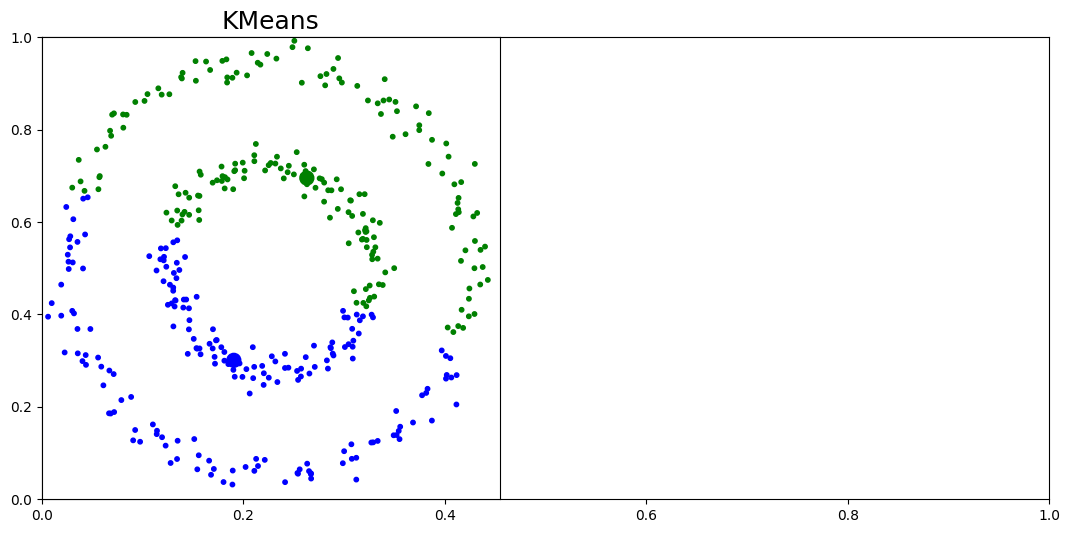

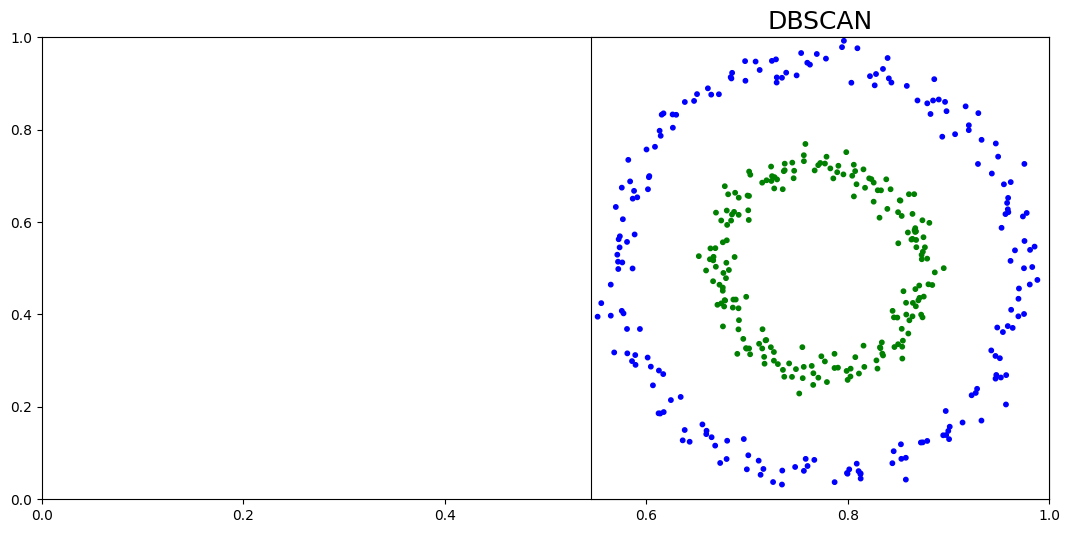

In [1]:
import time

import numpy as np
import matplotlib.pyplot as plt

from sklearn import cluster, datasets
from sklearn.neighbors import kneighbors_graph
from sklearn.preprocessing import StandardScaler

np.random.seed(0)

#you may change the parameters of the samples and the following toy sample functions
n_samples = 400
noisy_circles = datasets.make_circles(n_samples=n_samples, factor=0.5, noise=0.05)
X, y = noisy_circles
#blobs = datasets.make_blobs(n_samples=n_samples, random_state=9)
#X, y = blobs
#noisy_moons = datasets.make_moons(n_samples=n_samples, noise=.08)
#X, y = noisy_moons

X = StandardScaler().fit_transform(X)

#you may change the parameters of the clustering algorithm below
k_means = cluster.KMeans(n_clusters=2)
dbscan = cluster.DBSCAN(eps=.3)

colors = np.array([x for x in 'bgrcmykbgrcmykbgrcmykbgrcmyk'])
colors = np.hstack([colors] * 20)

clustering_names = ['KMeans', 'DBSCAN']
clustering_algorithms = [k_means, dbscan]

plot_num = 1

for name, algorithm in zip(clustering_names, clustering_algorithms):
        algorithm.fit(X)
        if hasattr(algorithm, 'labels_'):
            y_pred = algorithm.labels_.astype(int)
        else:
            y_pred = algorithm.predict(X)

        # plot
        plt.subplots(figsize=(13, 6))
        plt.subplot(1, len(clustering_algorithms), plot_num)
        plt.title(name, size=18)
        plt.scatter(X[:, 0], X[:, 1], color=colors[y_pred].tolist(), s=10)

        if hasattr(algorithm, 'cluster_centers_'):
            centers = algorithm.cluster_centers_
            center_colors = colors[:len(centers)]
            plt.scatter(centers[:, 0], centers[:, 1], s=100, c=center_colors)

        plt.xlim(-2, 2)
        plt.ylim(-2, 2)
        plt.xticks(())
        plt.yticks(())

        plot_num += 1


plt.show()

## 🔬 Experiment 1: Clustering on `blobs`

**Description:**  
This dataset consists of well-separated spherical clusters. It is ideal for algorithms that assume Gaussian-shaped distributions.



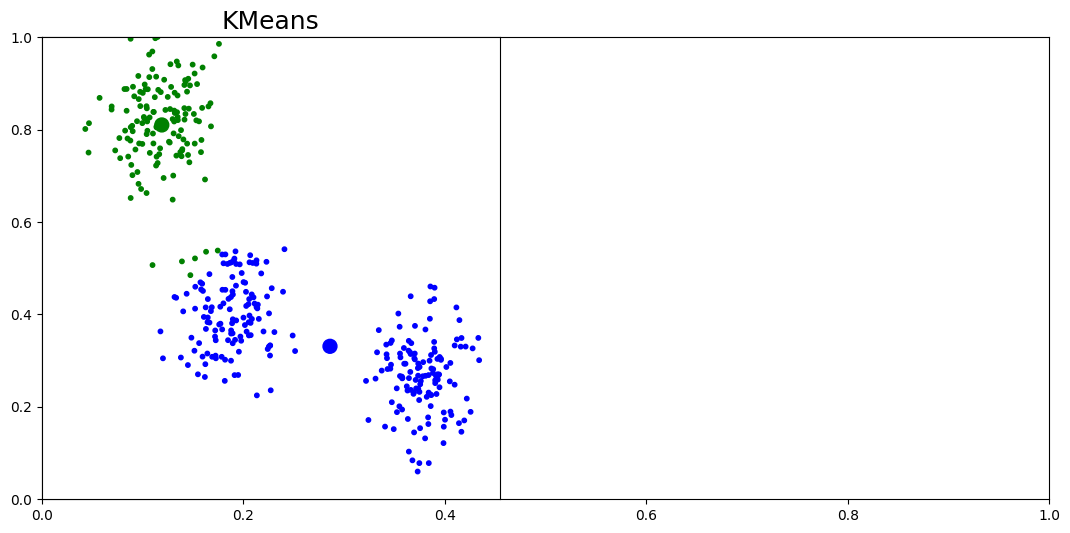

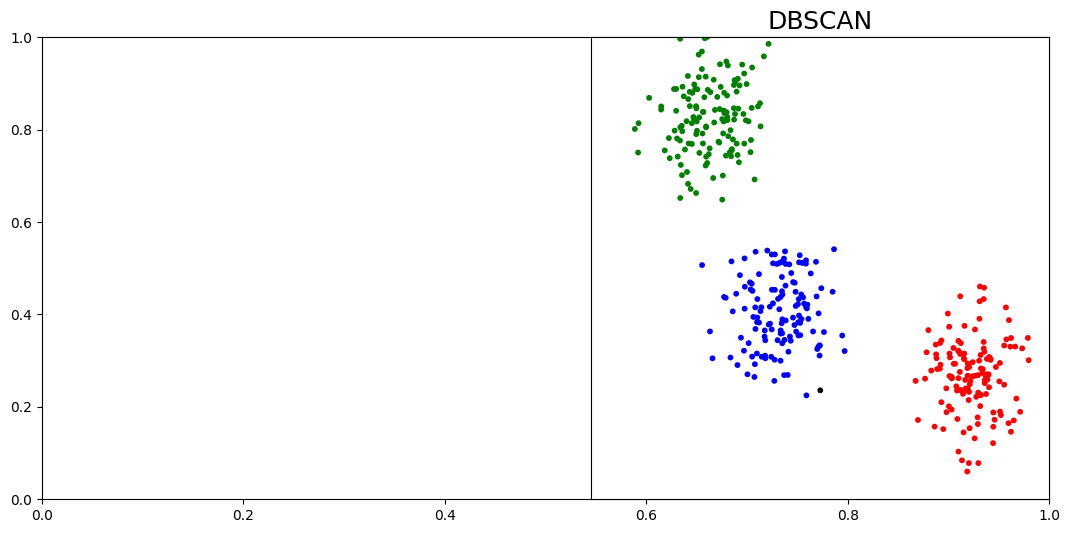

In [2]:
# Dataset: blobs
n_samples = 400
blobs = datasets.make_blobs(n_samples=n_samples, random_state=9)
X, y = blobs
X = StandardScaler().fit_transform(X)

# Clustering Algorithms
k_means = cluster.KMeans(n_clusters=2)
dbscan = cluster.DBSCAN(eps=0.3)

# Plot results
plot_num = 1
clustering_names = ['KMeans', 'DBSCAN']
clustering_algorithms = [k_means, dbscan]

for name, algorithm in zip(clustering_names, clustering_algorithms):
    algorithm.fit(X)
    y_pred = algorithm.labels_.astype(int) if hasattr(algorithm, 'labels_') else algorithm.predict(X)

    plt.subplots(figsize=(13, 6))
    plt.subplot(1, len(clustering_algorithms), plot_num)
    plt.title(name, size=18)
    plt.scatter(X[:, 0], X[:, 1], color=colors[y_pred].tolist(), s=10)
    if hasattr(algorithm, 'cluster_centers_'):
        centers = algorithm.cluster_centers_
        center_colors = colors[:len(centers)]
        plt.scatter(centers[:, 0], centers[:, 1], s=100, c=center_colors)

    plt.xlim(-2, 2)
    plt.ylim(-2, 2)
    plt.xticks(())
    plt.yticks(())
    plot_num += 1
plt.show()

**Observations:**
- **KMeans** performs very well, accurately detecting the clusters.
- **DBSCAN** can still detect clusters but is more sensitive to parameter tuning (e.g., `eps`, `min_samples`).
- If `eps` is too small, DBSCAN may label too many points as noise.

**Conclusion:**  
KMeans is the better algorithm for this type of data.

---

## 🌙 Experiment 2: Clustering on `noisy moons`

**Description:**  
This dataset contains two crescent-shaped clusters. It's a good test of an algorithm's ability to handle non-linear shapes.


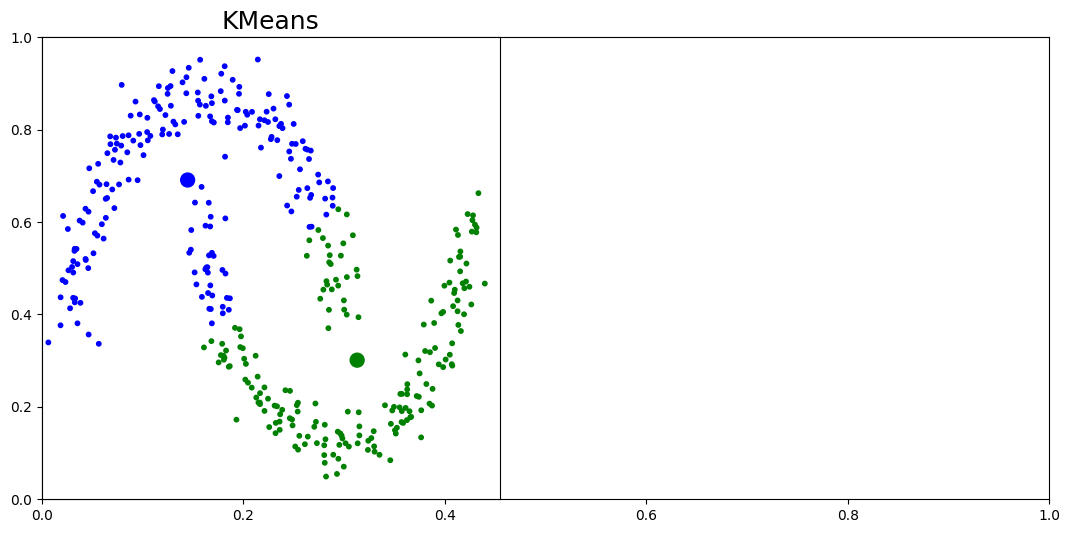

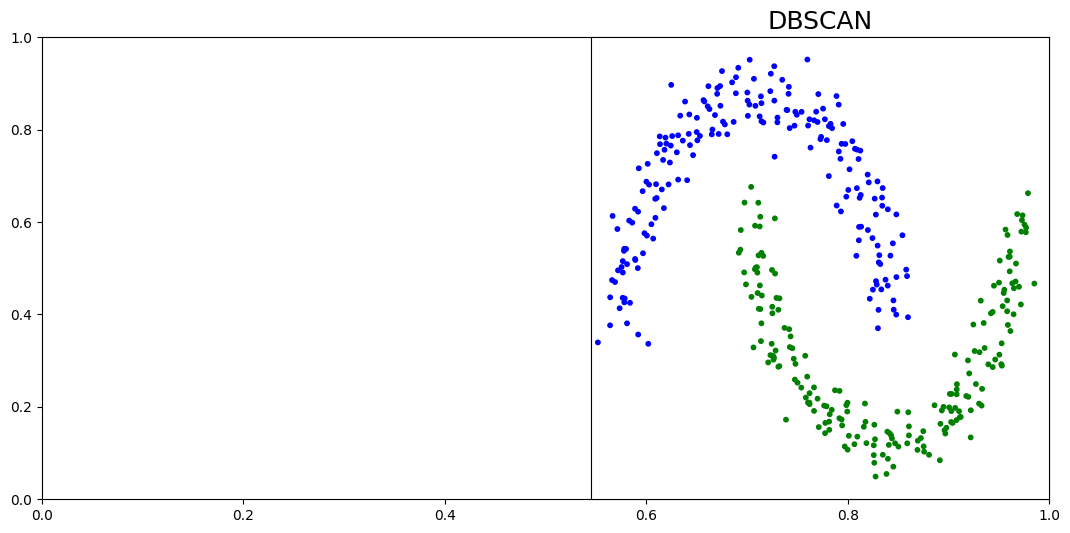

In [5]:
# Dataset: noisy moons
noisy_moons = datasets.make_moons(n_samples=n_samples, noise=0.08)
X, y = noisy_moons
X = StandardScaler().fit_transform(X)

# Clustering Algorithms
k_means = cluster.KMeans(n_clusters=2)
dbscan = cluster.DBSCAN(eps=0.3)

# Plot results
plot_num = 1
clustering_names = ['KMeans', 'DBSCAN']
clustering_algorithms = [k_means, dbscan]

for name, algorithm in zip(clustering_names, clustering_algorithms):
    algorithm.fit(X)
    y_pred = algorithm.labels_.astype(int) if hasattr(algorithm, 'labels_') else algorithm.predict(X)

    plt.subplots(figsize=(13, 6))
    plt.subplot(1, len(clustering_algorithms), plot_num)
    plt.title(name, size=18)
    plt.scatter(X[:, 0], X[:, 1], color=colors[y_pred].tolist(), s=10)
    if hasattr(algorithm, 'cluster_centers_'):
        centers = algorithm.cluster_centers_
        center_colors = colors[:len(centers)]
        plt.scatter(centers[:, 0], centers[:, 1], s=100, c=center_colors)

    plt.xlim(-2, 2)
    plt.ylim(-2, 2)
    plt.xticks(())
    plt.yticks(())
    plot_num += 1
plt.show()

**Observations:**
- **KMeans** performs poorly, cutting across the crescent shapes with linear boundaries.
- **DBSCAN** successfully detects the two curved clusters without requiring the number of clusters in advance.

**Conclusion:**  
DBSCAN significantly outperforms KMeans in non-linear clustering problems.

---


## 🌀 Experiment 3: Clustering on `noisy circles`

**Description:**  
This dataset contains concentric circles, representing clusters that are nested and non-convex.


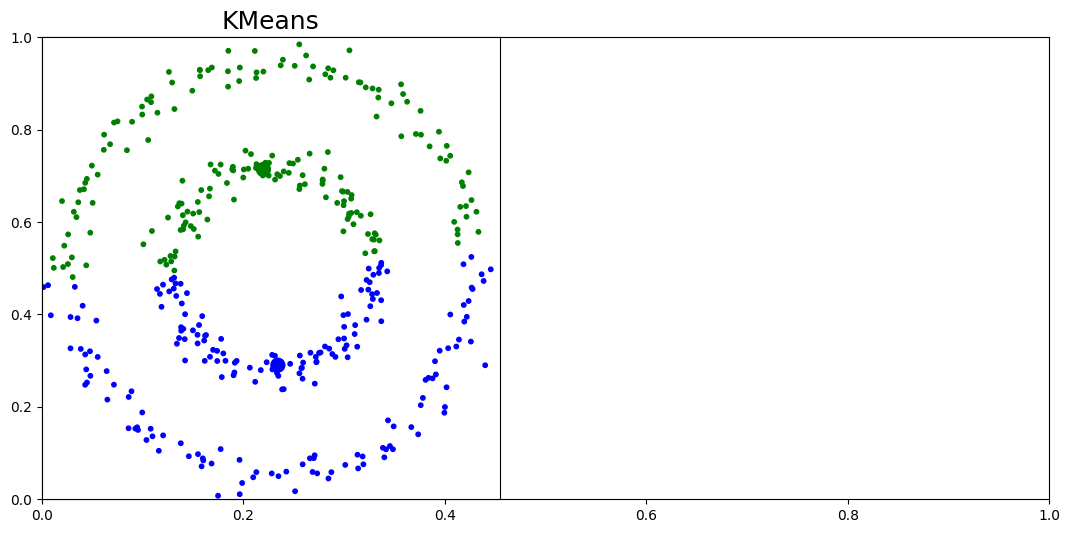

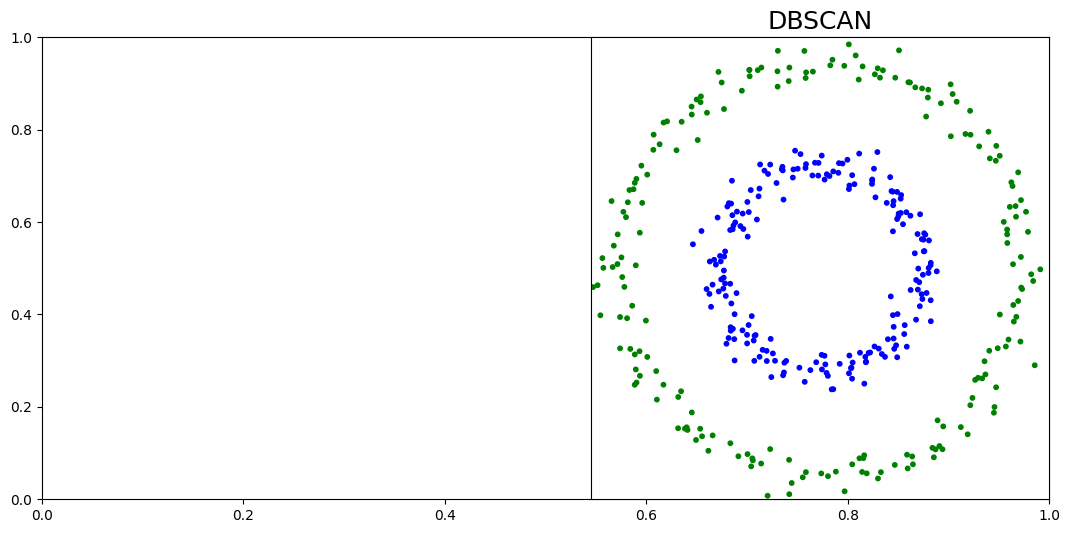

In [6]:
# Dataset: noisy circles
noisy_circles = datasets.make_circles(n_samples=n_samples, factor=0.5, noise=0.05)
X, y = noisy_circles
X = StandardScaler().fit_transform(X)

# Clustering Algorithms
k_means = cluster.KMeans(n_clusters=2)
dbscan = cluster.DBSCAN(eps=0.3)


# Plot results
plot_num = 1
clustering_names = ['KMeans', 'DBSCAN']
clustering_algorithms = [k_means, dbscan]

for name, algorithm in zip(clustering_names, clustering_algorithms):
    algorithm.fit(X)
    y_pred = algorithm.labels_.astype(int) if hasattr(algorithm, 'labels_') else algorithm.predict(X)

    plt.subplots(figsize=(13, 6))
    plt.subplot(1, len(clustering_algorithms), plot_num)
    plt.title(name, size=18)
    plt.scatter(X[:, 0], X[:, 1], color=colors[y_pred].tolist(), s=10)
    if hasattr(algorithm, 'cluster_centers_'):
        centers = algorithm.cluster_centers_
        center_colors = colors[:len(centers)]
        plt.scatter(centers[:, 0], centers[:, 1], s=100, c=center_colors)

    plt.xlim(-2, 2)
    plt.ylim(-2, 2)
    plt.xticks(())
    plt.yticks(())
    plot_num += 1
plt.show()

**Observations:**
- **KMeans** is unable to capture the circular structure, producing poor cluster separation.
- **DBSCAN** correctly identifies the inner and outer circles as distinct clusters.

**Conclusion:**  
DBSCAN handles complex shapes much better than KMeans in this case.

---


## ✅ Answers to Questions

### a) Is DBSCAN always better than KMeans?  
**No.** DBSCAN is not always better. For spherical and well-separated clusters (like blobs), KMeans performs better, is faster, and more stable.

---

### b) When is DBSCAN not better than KMeans?  
DBSCAN is not better when:
- The data consists of well-separated, circular (Gaussian) clusters.
- The `eps` parameter is not tuned properly, causing many noise points.
- The dataset is very large (DBSCAN is slower and more memory-intensive).

---

### c) Can KMeans be optimized to perform as well as DBSCAN?  
Only partially. KMeans assumes convex, isotropic clusters. While you can improve it by:
- Increasing `n_clusters`,
- Using feature transformations (e.g., PCA, kernel trick),
- Switching to advanced versions (Spectral Clustering),

…it still struggles with complex shapes (e.g., moons, circles) where DBSCAN naturally excels.

---

### d) Final Conclusion  

- **KMeans** is ideal for clean, spherical, well-separated data.
- **DBSCAN** excels in detecting arbitrary shapes and doesn't require the number of clusters to be specified.
- **There is no universal best algorithm** — the best choice depends on the data characteristics.
- **Experimentation is essential**, especially for DBSCAN's parameters (`eps`, `min_samples`), and for understanding the structure of your data.

---